In [7]:
import pandas as pd

titanic_df = pd.read_csv("update_titanic_data.csv")

titanic_df.head()

,Survived,initials,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,PStatus
0,0,Mr,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,False,S,3
1,1,Mrs,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,True,C,1
2,1,Miss,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,3
3,1,Mrs,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,True,S,1
4,0,Mr,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,False,S,3


In [2]:
titanic_df.corr(numeric_only=True)

,Survived,Age,SibSp,Parch,Fare,Cabin,PStatus
Survived,1.000000,-0.031700,-0.041842,0.068352,0.262637,0.331312,-0.363556
Age,-0.031700,1.000000,-0.255341,-0.172919,0.088553,0.199758,-0.311249
SibSp,-0.041842,-0.255341,1.000000,0.416784,0.163981,-0.032072,0.067405
Parch,0.068352,-0.172919,0.416784,1.000000,0.192788,0.032951,0.021608
Fare,0.262637,0.088553,0.163981,0.192788,1.000000,0.475071,-0.551805
Cabin,0.331312,0.199758,-0.032072,0.032951,0.475071,1.000000,-0.719004
PStatus,-0.363556,-0.311249,0.067405,0.021608,-0.551805,-0.719004,1.000000


<Axes: xlabel='Age', ylabel='Fare'>

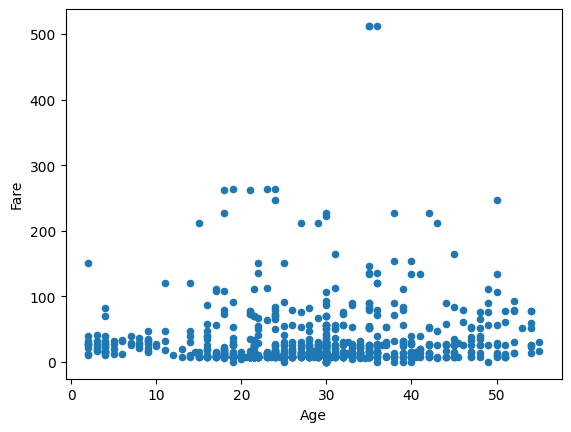

In [3]:
titanic_df.plot(kind = "scatter", x = "Age", y= "Fare")

<Axes: xlabel='Embarked', ylabel='PStatus'>

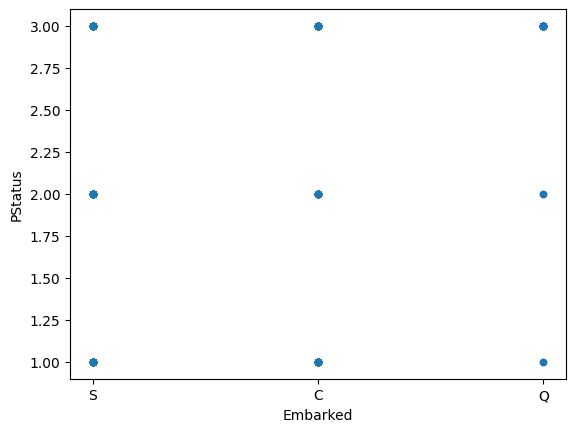

In [22]:
titanic_df.plot(kind = "scatter", x = "Embarked", y= "PStatus")

## Chi-Square Test

The chi-square test is a statistical test used to determine whether there is a significant association between categorical variables. It compares the observed frequencies of categories in a dataset to the expected frequencies under a specific hypothesis.

The test statistic for the chi-square test is calculated using the formula:

\begin{equation}
\chi^2 = \sum{\frac{{(O_i - E_i)^2}}{{E_i}}}
\end{equation}

where:
- $\chi^2$ is the chi-square test statistic
- $O_i$ is the observed frequency for each category
- $E_i$ is the expected frequency for each category, which is determined based on the null hypothesis


The **null hypothesis for the chi-square test is that there is no association between the categorical variables**, meaning the observed frequencies match the expected frequencies.

The chi-square test statistic follows a chi-square distribution with degrees of freedom determined by the number of categories and the constraints imposed by the null hypothesis.

In [9]:
from scipy.stats import chi2_contingency

In [11]:
contengency_table = pd.crosstab(titanic_df.PStatus, titanic_df.Survived)
contengency_table

Survived,0,1
PStatus,,
1,64,124
2,91,81
3,364,112


In [14]:
chi2_score, pvalue, dof, expected_freq = chi2_contingency(contengency_table)

print(f"Chi-Square test score = {round(chi2_score, 3)}")
print(f"p-value = {round(pvalue, 5)}")

Chi-Square test score = 110.803
p-value = 0.0


**Interpreting the results**

- The chi-square test statistic measures the difference between the observed and expected frequencies. A larger test statistic indicates a larger deviation from the expected frequencies.
- The p-value represents the probability of observing a test statistic as extreme as the one calculated, assuming the null hypothesis is true. A small p-value (typically below a significance level such as 0.05) suggests rejecting the null hypothesis in favor of the alternative hypothesis.
- The expected frequencies are the frequencies that would be expected under the null hypothesis. Comparing the observed frequencies to the expected frequencies provides insights into the association between the categorical variables.


In [16]:
# We find a relation between colum , PStatus and Survived.

In [17]:
contengency_table = pd.crosstab(titanic_df.Embarked, titanic_df.SibSp)
contengency_table

SibSp,0.0,1.0,2.0,3.0,4.0,5.0,8.0
Embarked,,,,,,,
C,97,51,4,0,0,0,0
Q,56,11,3,0,4,0,0
S,416,136,18,16,13,4,7


In [18]:
chi2_score, pvalue, dof, expected_freq = chi2_contingency(contengency_table)

print(f"Chi-Square test score = {round(chi2_score, 3)}")
print(f"p-value = {round(pvalue, 5)}")

Chi-Square test score = 27.821
p-value = 0.00588


In [20]:
# Example

data = pd.DataFrame(
    {
        "category": ["A", "B", "C", "A","C","B","A"],
        "outcome": ["true", "false", "true", "false","true","true","false"],
    }
)
data

,category,outcome
0,A,true
1,B,false
2,C,true
3,A,false
4,C,true
5,B,true
6,A,false


In [21]:
contengency_table = pd.crosstab(data.category, data.outcome)

chi2_score, pvalue, dof, expected_freq = chi2_contingency(contengency_table)

print(f"Chi-Square test score = {round(chi2_score, 3)}")
print(f"p-value = {round(pvalue, 5)}")

Chi-Square test score = 2.236
p-value = 0.32691
